# Dense periodic n=1 volatility forecasting

## Step 4 objective

Construct three one-step conditional volatility forecasts from training-only observable estimates. This notebook stops at forecast construction and mechanical validation; it deliberately performs no Step 5 accuracy, ranking, calibration, or interval analysis.


## 2. Forecast timing and information set

The forecast for $\sigma_{i+1}$ is issued after $S_{i+1}$ is observed, while $\sigma_i$ remains known and before the delayed observation of $\sigma_{i+1}$. It is therefore a one-step conditional volatility forecast (or conditional volatility nowcast), not an ordinary ex-ante forecast from $t_i$. Allowed transition-$i$ inputs are $S_i$, $S_{i+1}$, $\sigma_i$, $\Delta t_i$, the event calendar, the event age, and training-fitted parameters.


## 3. Governing forecast equations

For $n=1$, the common observable baseline estimates $\widehat F_i=\hat\beta_0+\hat\beta_\sigma\sigma_i+\hat\beta_\epsilon\widehat\epsilon_i$, where $\widehat\epsilon_i=((S_{i+1}-S_i)/S_i)/\sigma_i$. Each forecast is $\widehat\sigma_{i+1}=\widehat m_{i+1}\widehat F_i$. The event-unaware multiplier is one; the parametric multiplier is $\sqrt{1+\hat A\exp(-\hat\lambda a/\mathrm{steps\ per\ year})}$; and the non-parametric multiplier is the training mean raw multiplier for age $a$.

The latent $\eta_i$ term in $F_i=\sigma_i+\alpha_i\Delta t_i+\nu_i[\rho_i\epsilon_i+\sqrt{1-\rho_i^2}\eta_i]$ is not forecastable. Its conditional mean is zero, so the OLS baseline estimates the observable conditional-mean contribution without reconstructing $\eta_i$, realised hidden $F_i$, or true event quantities.


## 4. Load Notebook 00 and imports


In [14]:
%%capture
%run "./00_model_specification_and_core_simulator.ipynb"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import least_squares

pd.set_option('display.precision', 6)

upstream_notebooks = ['00_model_specification_and_core_simulator.ipynb']
step5_outputs_created = []


## 5. Regenerate the dense periodic n=1 benchmark

Only Notebook 00 is executed upstream. The reference schedule, path, and all timing are inherited dynamically.


In [15]:
model_params = reference_config['model']
event_params = reference_config['events']
simulation_params = reference_config['simulation']
steps_per_year = reference_timing['steps_per_year']
event_period_steps = reference_timing['event_period_steps']
response_horizon_steps = reference_timing['response_horizon_steps']
event_transition_ages = list(reference_timing['event_transition_ages'])

if model_params['n'] != 1:
    raise ValueError('Notebook 04 implements the dense periodic n=1 forecast only.')
if reference_timing['event_responses_overlap']:
    raise ValueError("Notebook 04's single-event-age representation requires non-overlapping event responses.")

n_steps = int(simulation_params['years'] * steps_per_year)
time_grid = np.arange(n_steps + 1, dtype=float) / steps_per_year
event_times = periodic_event_times(time_grid[0], time_grid[-2], event_params)
regenerated_result = simulate_event_volatility(
    time_grid=time_grid, S0=simulation_params['S0'], sigma0=simulation_params['sigma0'],
    n=model_params['n'], alpha_fn=alpha_fn, nu_fn=nu_fn, rho_fn=rho_fn,
    event_weight_fn=event_weight_fn, model_params=model_params, event_times=event_times,
    event_params=event_params, seed=simulation_params['seed'],
)
states = regenerated_result['states'].copy()
transitions = regenerated_result['transitions'].copy()
pd.testing.assert_frame_equal(states, reference_result['states'])
pd.testing.assert_frame_equal(transitions, reference_result['transitions'])
assert len(event_times) == int(transitions['event'].sum())
print(f'Regenerated {len(transitions)} transitions with reference seed {simulation_params["seed"]}.')


Regenerated 504 transitions with reference seed 20260721.


## 6. Build the aligned observable forecasting table

Age zero is the event affecting transition $i\to i+1$ and hence $\sigma_{i+1}$. Event history is constructed from valid source transitions only.


In [16]:
analysis_table = pd.DataFrame({
    'i': transitions['i'].to_numpy(),
    'target_i': transitions['target_i'].to_numpy(),
    't_i': transitions['t'].to_numpy(),
    'dt_i': transitions['dt'].to_numpy(),
    'S_i': states['S'].iloc[:-1].to_numpy(),
    'S_next': states['S'].iloc[1:].to_numpy(),
    'sigma_i': states['sigma'].iloc[:-1].to_numpy(),
    'sigma_next': states['sigma'].iloc[1:].to_numpy(),
    'event_i': transitions['event'].to_numpy(dtype=int),
})
analysis_table['simple_return_i'] = (analysis_table['S_next'] - analysis_table['S_i']) / analysis_table['S_i']
analysis_table['epsilon_proxy_i'] = analysis_table['simple_return_i'] / analysis_table['sigma_i']
event_features = []
for age in event_transition_ages:
    name = f'event_lag_{age}'
    analysis_table[name] = analysis_table['event_i'].shift(age)
    event_features.append(name)
analysis_table = analysis_table.iloc[response_horizon_steps:].copy().reset_index(drop=True)
analysis_table[event_features] = analysis_table[event_features].astype(int)
analysis_table['event_active_i'] = analysis_table[event_features].sum(axis=1).astype(int)
active_age_matrix = analysis_table[event_features].to_numpy(dtype=int)
analysis_table['event_age_i'] = np.where(
    analysis_table['event_active_i'].eq(1), active_age_matrix.argmax(axis=1), -1
).astype(int)
analysis_table['event_age_years_i'] = np.where(
    analysis_table['event_active_i'].eq(1), analysis_table['event_age_i'] / steps_per_year, np.nan
)
assert analysis_table.drop(columns=['event_age_years_i']).notna().all().all()
assert analysis_table.loc[analysis_table['event_active_i'].eq(0), 'event_age_years_i'].isna().all()
assert set(analysis_table['event_age_i'].loc[analysis_table['event_active_i'].eq(1)]) == set(event_transition_ages)
print(f'Usable rows: {len(analysis_table)}; active rows: {int(analysis_table.event_active_i.sum())}.')
display(analysis_table.head())


Usable rows: 492; active rows: 299.


,i,target_i,t_i,dt_i,S_i,S_next,sigma_i,sigma_next,event_i,simple_return_i,...,event_lag_6,event_lag_7,event_lag_8,event_lag_9,event_lag_10,event_lag_11,event_lag_12,event_active_i,event_age_i,event_age_years_i
0,12,13,0.047619,0.003968,102.751010,102.087857,0.195601,0.195878,0,-0.006454,...,0,0,0,0,0,0,0,0,-1,NaN
1,13,14,0.051587,0.003968,102.087857,102.490211,0.195878,0.196371,0,0.003941,...,0,0,0,0,0,0,0,0,-1,NaN
2,14,15,0.055556,0.003968,102.490211,101.771270,0.196371,0.195697,0,-0.007015,...,0,0,0,0,0,0,0,0,-1,NaN
3,15,16,0.059524,0.003968,101.771270,100.296205,0.195697,0.195363,0,-0.014494,...,0,0,0,0,0,0,0,0,-1,NaN
4,16,17,0.063492,0.003968,100.296205,100.888858,0.195363,0.194100,0,0.005909,...,0,0,0,0,0,0,0,0,-1,NaN


## 7. Chronological train-test split

The test sample begins at the first exact age-zero event at or after the approximate 70% position, matching the Step 3 split rule.


In [17]:
approximate_split = int(np.floor(0.70 * len(analysis_table)))
future_event_positions = np.flatnonzero(
    analysis_table['event_lag_0'].iloc[approximate_split:].to_numpy() == 1
)
if len(future_event_positions) == 0:
    raise ValueError('No age-zero event is available at or after the approximate chronological split.')
test_start = approximate_split + int(future_event_positions[0])
train_data = analysis_table.iloc[:test_start].copy()
test_data = analysis_table.iloc[test_start:].copy()
assert train_data['t_i'].max() < test_data['t_i'].min()
assert int(test_data['event_lag_0'].iloc[0]) == 1
for age in event_transition_ages:
    assert (train_data['event_age_i'].eq(age)).any()
    assert (test_data['event_age_i'].eq(age)).any()
split_summary = pd.DataFrame([{
    'training_rows': len(train_data), 'testing_rows': len(test_data),
    'test_start_i': int(test_data['i'].iloc[0]), 'test_start_t': float(test_data['t_i'].iloc[0]),
    'training_active_rows': int(train_data['event_active_i'].sum()),
    'testing_active_rows': int(test_data['event_active_i'].sum()),
}])
display(split_summary)


,training_rows,testing_rows,test_start_i,test_start_t,training_active_rows,testing_active_rows
0,345,147,357,1.416667,208,91


## 8. Common event-free OLS baseline

All three primary forecasts use the same OLS baseline, fitted only on event-free training transitions. A random forest is deliberately omitted: its chronological support-shift weakness in Step 3 would confound baseline choice with the event-profile comparison.


In [18]:
baseline_feature_columns = ['sigma_i', 'epsilon_proxy_i']
hidden_simulator_names = {'epsilon', 'eta', 'F', 'omega', 'true_omega', 'true_amplitude', 'true_decay_rate'}
event_free_train = train_data.loc[train_data['event_active_i'].eq(0)].copy()
ols_baseline = sm.OLS(
    event_free_train['sigma_next'], sm.add_constant(event_free_train[baseline_feature_columns], has_constant='add')
).fit()
ols_coefficients = ols_baseline.params.rename('estimate').to_frame()
print(ols_coefficients.to_string())

def ols_baseline_prediction(frame):
    return np.asarray(ols_baseline.predict(sm.add_constant(frame[baseline_feature_columns], has_constant='add')), dtype=float)

analysis_table['F_hat_ols'] = ols_baseline_prediction(analysis_table)
if not np.isfinite(analysis_table['F_hat_ols']).all() or not analysis_table['F_hat_ols'].gt(0).all():
    raise ValueError('The OLS baseline produced a non-finite or non-positive conditional forecast.')


                 estimate
const            0.001754
sigma_i          0.991565
epsilon_proxy_i -0.007568


## 9. Training-only raw multiplier proxy

The raw multiplier $m_{raw,i}=\sigma_{i+1}/\widehat F_i$ is used only on training observations to estimate the two event profiles. It is not clipped.


In [19]:
train_data = analysis_table.loc[analysis_table['i'].isin(train_data['i'])].copy()
test_data = analysis_table.loc[analysis_table['i'].isin(test_data['i'])].copy()
train_data['m_raw'] = train_data['sigma_next'] / train_data['F_hat_ols']
if not np.isfinite(train_data['m_raw']).all() or not train_data['m_raw'].gt(0).all():
    raise ValueError('Training raw multiplier proxy must be finite and strictly positive.')
active_train = train_data.loc[train_data['event_active_i'].eq(1)].copy()


## 10. Parametric event profile

A bounded nonlinear least-squares fit uses active training rows only. Initial values are derived from those observed raw multipliers, never from true event parameters.


In [20]:
initial_amplitude = max(float(np.square(active_train['m_raw'].median()) - 1.0), 1e-8)
initial_decay = max(float(1.0 / max(active_train['event_age_years_i'].replace(0, np.nan).median(), 1.0 / steps_per_year)), 1e-8)
parametric_initial_values = np.array([initial_amplitude, initial_decay], dtype=float)

def parametric_multiplier(parameters, age_years):
    amplitude, decay = parameters
    return np.sqrt(1.0 + amplitude * np.exp(-decay * age_years))

def parametric_residuals(parameters, age_years, observed_multiplier):
    return parametric_multiplier(parameters, age_years) - observed_multiplier

parametric_fit = least_squares(
    parametric_residuals, x0=parametric_initial_values,
    bounds=(np.zeros(2), np.full(2, np.inf)),
    args=(active_train['event_age_years_i'].to_numpy(), active_train['m_raw'].to_numpy()),
)
A_hat, lambda_hat = map(float, parametric_fit.x)
print(f'A_hat={A_hat:.8g}; lambda_hat={lambda_hat:.8g}; converged={parametric_fit.success}')


A_hat=0.0084056116; lambda_hat=36.085838; converged=True


## 11. Non-parametric event-age profile

The primary non-parametric estimator is the training mean raw multiplier in each event-age cell. No smoothing, monotonicity, or lower weight constraint is imposed.


In [21]:
age_profile = active_train.groupby('event_age_i')['m_raw'].agg(['count', 'mean', 'std', 'median']).reindex(event_transition_ages)
age_profile['standard_error'] = age_profile['std'] / np.sqrt(age_profile['count'])
if age_profile['count'].isna().any() or age_profile['count'].lt(1).any():
    raise ValueError('Every configured event-age cell requires at least one active training observation.')
nonparametric_multiplier_by_age = age_profile['mean'].to_dict()
display(age_profile)


,count,mean,std,median,standard_error
event_age_i,,,,,
0,16,1.004008,0.004879,1.003757,0.001220
1,16,1.002670,0.004463,1.002597,0.001116
2,16,1.003238,0.003398,1.003192,0.000850
3,16,1.004868,0.004626,1.004547,0.001157
4,16,1.002394,0.005648,1.002870,0.001412
5,16,1.001692,0.004653,1.001611,0.001163
6,16,1.001806,0.004962,1.002683,0.001240
7,16,1.000718,0.003398,1.001135,0.000850
8,16,1.001771,0.004207,1.001752,0.001052


## 12. Freeze fitted estimators

The OLS coefficients, parametric profile, and event-age means are copied before any test forecast is generated. No test-period target is used in fitting or update.


In [22]:
frozen_ols_coefficients = ols_baseline.params.copy()
frozen_A_hat = float(A_hat)
frozen_lambda_hat = float(lambda_hat)
frozen_nonparametric_profile = age_profile['mean'].copy()
assert frozen_nonparametric_profile.index.tolist() == event_transition_ages
assert np.isfinite([frozen_A_hat, frozen_lambda_hat]).all() and frozen_A_hat >= 0 and frozen_lambda_hat >= 0


## 13. Construct the three test forecast variants

The dedicated forecast-input table deliberately excludes $\sigma_{i+1}$. The existing target remains outside it and is not used in forecast generation.


In [23]:
forecast_input_columns = [
    'i', 'target_i', 't_i', 'dt_i', 'S_i', 'S_next', 'sigma_i', 'simple_return_i',
    'epsilon_proxy_i', 'event_i', 'event_active_i', 'event_age_i', 'event_age_years_i',
]
test_forecast_table = test_data[forecast_input_columns].copy()
assert 'sigma_next' not in test_forecast_table.columns

test_forecast_table['F_hat_ols'] = ols_baseline_prediction(test_forecast_table)
if not np.isfinite(test_forecast_table['F_hat_ols']).all() or not test_forecast_table['F_hat_ols'].gt(0).all():
    raise ValueError('A test OLS baseline forecast is non-finite or non-positive.')
active = test_forecast_table['event_active_i'].eq(1)
test_forecast_table['multiplier_hat_unaware'] = 1.0
test_forecast_table['multiplier_hat_parametric'] = 1.0
test_forecast_table.loc[active, 'multiplier_hat_parametric'] = parametric_multiplier(
    np.array([frozen_A_hat, frozen_lambda_hat]),
    test_forecast_table.loc[active, 'event_age_years_i'].to_numpy(),
)
test_forecast_table['multiplier_hat_nonparametric'] = 1.0
test_forecast_table.loc[active, 'multiplier_hat_nonparametric'] = test_forecast_table.loc[active, 'event_age_i'].map(frozen_nonparametric_profile)
test_forecast_table['omega_hat_parametric'] = test_forecast_table['multiplier_hat_parametric'] ** 2
test_forecast_table['omega_hat_nonparametric'] = test_forecast_table['multiplier_hat_nonparametric'] ** 2
test_forecast_table['sigma_forecast_unaware'] = test_forecast_table['F_hat_ols']
test_forecast_table['sigma_forecast_parametric'] = test_forecast_table['multiplier_hat_parametric'] * test_forecast_table['F_hat_ols']
test_forecast_table['sigma_forecast_nonparametric'] = test_forecast_table['multiplier_hat_nonparametric'] * test_forecast_table['F_hat_ols']
assert test_forecast_table.drop(columns=['event_age_years_i']).notna().all().all()
assert test_forecast_table.loc[test_forecast_table['event_active_i'].eq(0), 'event_age_years_i'].isna().all()


## 14. Forecast mechanics tables and plots

The true synthetic event multiplier is shown only after all estimators are frozen, as a reference that was never used for fitting or forecasting. Realised $\sigma_{i+1}$ is retrieved separately only after forecast construction for a qualitative illustration. It contains the unpredictable $\eta_i$ innovation, whereas the forecasts estimate a conditional mean; exact path matching is neither expected nor required. No accuracy metric is calculated here.


,test_forecasts,active_test_rows,event_free_test_rows,configured_event_ages,OLS_baseline_features
0,147,91,56,13,"sigma_i, epsilon_proxy_i"


,i,target_i,t_i,dt_i,S_i,S_next,sigma_i,simple_return_i,epsilon_proxy_i,event_i,...,event_age_years_i,F_hat_ols,multiplier_hat_unaware,multiplier_hat_parametric,multiplier_hat_nonparametric,omega_hat_parametric,omega_hat_nonparametric,sigma_forecast_unaware,sigma_forecast_parametric,sigma_forecast_nonparametric
345,357,358,1.416667,0.003968,94.821470,92.715920,0.241007,-0.022205,-0.092136,1,...,0.000000,0.241425,1.0,1.004194,1.004008,1.008406,1.008031,0.241425,0.242437,0.242392
346,358,359,1.420635,0.003968,92.715920,92.541011,0.241906,-0.001887,-0.007799,0,...,0.003968,0.241678,1.0,1.003635,1.002670,1.007284,1.005346,0.241678,0.242557,0.242323
347,359,360,1.424603,0.003968,92.541011,91.204517,0.241951,-0.014442,-0.059690,0,...,0.007937,0.242116,1.0,1.003151,1.003238,1.006312,1.006486,0.242116,0.242879,0.242900
348,360,361,1.428571,0.003968,91.204517,92.045389,0.242894,0.009220,0.037957,0,...,0.011905,0.242311,1.0,1.002731,1.004868,1.005470,1.009760,0.242311,0.242973,0.243491
349,361,362,1.432540,0.003968,92.045389,92.343123,0.243580,0.003235,0.013280,0,...,0.015873,0.243178,1.0,1.002367,1.002394,1.004740,1.004794,0.243178,0.243754,0.243760
350,362,363,1.436508,0.003968,92.343123,93.926772,0.244098,0.017150,0.070257,0,...,0.019841,0.243261,1.0,1.002052,1.001692,1.004108,1.003388,0.243261,0.243760,0.243673
351,363,364,1.440476,0.003968,93.926772,92.327254,0.244718,-0.017029,-0.069588,0,...,0.023810,0.244934,1.0,1.001778,1.001806,1.003560,1.003616,0.244934,0.245369,0.245376
352,364,365,1.444444,0.003968,92.327254,91.685959,0.244380,-0.006946,-0.028422,0,...,0.027778,0.244287,1.0,1.001541,1.000718,1.003085,1.001436,0.244287,0.244664,0.244463
353,365,366,1.448413,0.003968,91.685959,88.205200,0.243240,-0.037964,-0.156076,0,...,0.031746,0.244123,1.0,1.001336,1.001771,1.002673,1.003546,0.244123,0.244449,0.244556
354,366,367,1.452381,0.003968,88.205200,89.010514,0.243907,0.009130,0.037432,0,...,0.035714,0.243320,1.0,1.001158,1.002193,1.002317,1.004392,0.243320,0.243602,0.243854


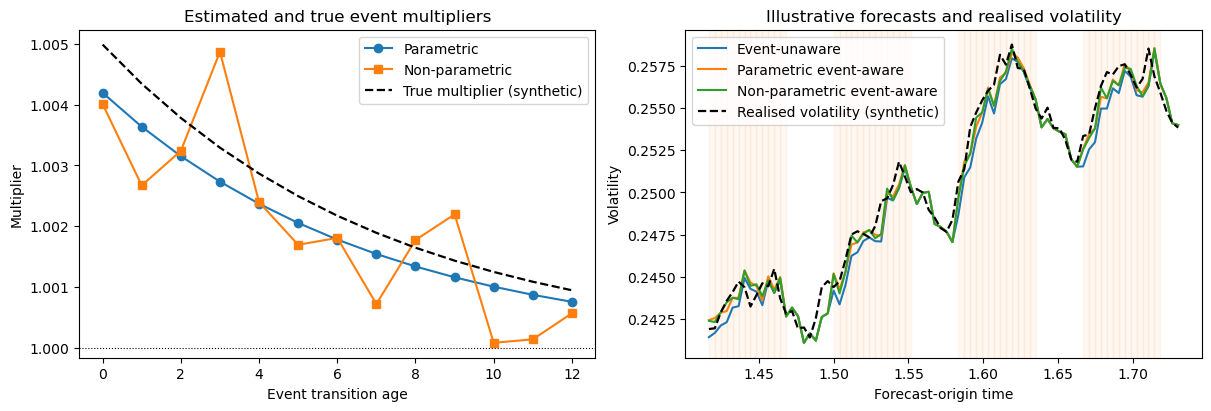

In [24]:
forecast_mechanics_summary = pd.DataFrame([{
    'test_forecasts': len(test_forecast_table),
    'active_test_rows': int(active.sum()),
    'event_free_test_rows': int((~active).sum()),
    'configured_event_ages': len(event_transition_ages),
    'OLS_baseline_features': ', '.join(baseline_feature_columns),
}])
display(forecast_mechanics_summary)
display(test_forecast_table.head(12))

# Synthetic truth is accessed only after fitting and frozen forecast generation.
true_event_amplitude = reference_config['events']['amplitude']
true_decay_rate = reference_config['events']['decay_rate']
profile_plot = pd.DataFrame({
    'event_age': event_transition_ages,
    'parametric_multiplier': parametric_multiplier(np.array([frozen_A_hat, frozen_lambda_hat]), np.asarray(event_transition_ages) / steps_per_year),
    'nonparametric_multiplier': [frozen_nonparametric_profile.loc[a] for a in event_transition_ages],
})
profile_plot['true_multiplier_synthetic'] = np.sqrt(
    1.0 + true_event_amplitude * np.exp(-true_decay_rate * profile_plot['event_age'] / steps_per_year)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(profile_plot['event_age'], profile_plot['parametric_multiplier'], marker='o', label='Parametric')
axes[0].plot(profile_plot['event_age'], profile_plot['nonparametric_multiplier'], marker='s', label='Non-parametric')
axes[0].plot(profile_plot['event_age'], profile_plot['true_multiplier_synthetic'], color='black', linestyle='--', linewidth=1.6, label='True multiplier (synthetic)')
axes[0].axhline(1.0, color='black', linewidth=0.8, linestyle=':')
axes[0].set(title='Estimated and true event multipliers', xlabel='Event transition age', ylabel='Multiplier')
axes[0].legend()

segment = test_forecast_table.head(min(80, len(test_forecast_table))).copy()
# The realised target is aligned only after all forecasts exist; it never enters the forecast-input table.
realised_segment = test_data.set_index('i').loc[segment['i'], 'sigma_next'].to_numpy()
for column, label in [
    ('sigma_forecast_unaware', 'Event-unaware'),
    ('sigma_forecast_parametric', 'Parametric event-aware'),
    ('sigma_forecast_nonparametric', 'Non-parametric event-aware'),
]:
    axes[1].plot(segment['t_i'], segment[column], label=label)
axes[1].plot(segment['t_i'], realised_segment, color='black', linestyle='--', linewidth=1.6, label='Realised volatility (synthetic)')
for _, row in segment.loc[segment['event_active_i'].eq(1)].iterrows():
    axes[1].axvspan(row['t_i'], row['t_i'] + row['dt_i'], color='tab:orange', alpha=0.05)
axes[1].set(title='Illustrative forecasts and realised volatility', xlabel='Forecast-origin time', ylabel='Volatility')
axes[1].legend()
plt.show()


## 15. Final Step 4 findings and handoff to Step 5

Three mechanically valid conditional-volatility forecast variants have been constructed with a common training-only OLS baseline. The only difference between the event-aware variants is their frozen training-fitted event multiplier. The latent $\eta_i$ innovation remains irreducible. No recursive forecast, Step 5 accuracy or calibration analysis, or upstream execution beyond Notebook 00 is performed here. Step 5 may evaluate the completed forecast columns against delayed realised volatility.


In [26]:
print(f'OLS coefficients: {ols_baseline.params.to_dict()}')
print(f'Parametric profile: A_hat={frozen_A_hat:.8g}, lambda_hat={frozen_lambda_hat:.8g}.')
print(f'Non-parametric event-age cells: {len(frozen_nonparametric_profile)}.')
print(f'Training/testing rows: {len(train_data)}/{len(test_data)}; forecasts created: {len(test_forecast_table)}.')
print('No Step 5 forecast-accuracy, ranking, or calibration evaluation has been performed.')


OLS coefficients: {'const': 0.001753552449697257, 'sigma_i': 0.9915645044878663, 'epsilon_proxy_i': -0.007567666918341154}
Parametric profile: A_hat=0.0084056116, lambda_hat=36.085838.
Non-parametric event-age cells: 13.
Training/testing rows: 345/147; forecasts created: 147.
No Step 5 forecast-accuracy, ranking, or calibration evaluation has been performed.
